Install and Import

In [ ]:
!pip -q install pandas numpy matplotlib seaborn openpyxl python-dateutil

import os
import re
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil import parser

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

# Mount Google Drive so CSVs and outputs are stored centrally
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/northstar_dataset1"

print("Exists:", os.path.exists(BASE_PATH))
print("Files:")
print(os.listdir(BASE_PATH))

Exists: True
Files:
['deliveries.csv', 'orders.csv', 'customers.csv', 'vehicles.csv', 'drivers.csv', 'hubs.csv', 'app_events.csv', 'data_dictionary.csv', 'incidents.csv', 'complaints.csv', 'README.txt']


Define Paths

In [ ]:
BASE_PATH = "/content/drive/MyDrive/northstar_dataset1"

RAW_FILES = {
    "app_events": "app_events.csv",
    "complaints": "complaints.csv",
    "customers": "customers.csv",
    "data_dictionary": "data_dictionary.csv",
    "deliveries": "deliveries.csv",
    "drivers": "drivers.csv",
    "hubs": "hubs.csv",
    "incidents": "incidents.csv",
    "orders": "orders.csv",
    "vehicles": "vehicles.csv",  # keep original filename if misspelled
    "readme": "README.txt"
}

OUTPUT_PATH = os.path.join(BASE_PATH, "output")
PLOTS_PATH = os.path.join(OUTPUT_PATH, "plots")
REPORTS_PATH = os.path.join(OUTPUT_PATH, "reports")

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

print("Base path:", BASE_PATH)
print("Output path:", OUTPUT_PATH)

Base path: /content/drive/MyDrive/northstar_dataset1
Output path: /content/drive/MyDrive/northstar_dataset1/output


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/northstar_dataset1"

print(os.path.exists(BASE_PATH))
print(os.listdir(BASE_PATH))

True
['deliveries.csv', 'orders.csv', 'customers.csv', 'vehicles.csv', 'drivers.csv', 'hubs.csv', 'app_events.csv', 'data_dictionary.csv', 'incidents.csv', 'complaints.csv', 'README.txt', 'output']


Load CSVs and README

In [ ]:
def read_csv_flexible(path):
    """Try a few encodings so we don't crash on weird characters."""
    encodings = ["utf-8", "latin1", "cp1252"]
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    return pd.read_csv(path, encoding="utf-8", errors="ignore")

dfs = {}

for name, fname in RAW_FILES.items():
    fpath = os.path.join(BASE_PATH, fname)
    if not os.path.exists(fpath):
        print(f"[WARNING] File not found: {fname}")
        continue

    if fname.lower().endswith(".csv"):
        dfs[name] = read_csv_flexible(fpath)
    elif fname.lower().endswith(".txt"):
        with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
            dfs[name] = f.read()

print("Loaded datasets:", list(dfs.keys()))

# Convenience aliases
app_events = dfs.get("app_events", pd.DataFrame())
complaints = dfs.get("complaints", pd.DataFrame())
customers = dfs.get("customers", pd.DataFrame())
data_dictionary = dfs.get("data_dictionary", pd.DataFrame())
deliveries = dfs.get("deliveries", pd.DataFrame())
drivers = dfs.get("drivers", pd.DataFrame())
hubs = dfs.get("hubs", pd.DataFrame())
incidents = dfs.get("incidents", pd.DataFrame())
orders = dfs.get("orders", pd.DataFrame())
vehicles = dfs.get("vehicles", pd.DataFrame())

if "readme" in dfs:
    print("\nREADME preview:\n")
    print(str(dfs["readme"])[:1500])

Loaded datasets: ['app_events', 'complaints', 'customers', 'data_dictionary', 'deliveries', 'drivers', 'hubs', 'incidents', 'orders', 'vehicles', 'readme']

README preview:

NorthStar Dataset

This dataset includes:

- inconsistent categorical values
- missing values
- cross-file relationships
- hidden operational delay/failure patterns
- customer complaints and incident records
- app event data that can be remodelled for MongoDB Atlas

Students can:
- query structured data with SQL in R
- perform analytics in R
- clean and engineer features in Python
- remodel selected files into MongoDB Atlas collections



Basic Profiling

In [ ]:
dataset_dict = {
    "app_events": app_events,
    "complaints": complaints,
    "customers": customers,
    "data_dictionary": data_dictionary,
    "deliveries": deliveries,
    "drivers": drivers,
    "hubs": hubs,
    "incidents": incidents,
    "orders": orders,
    "vehicles": vehicles
}

profile_rows = []

for name, df in dataset_dict.items():
    if df is None or df.empty:
        continue
    profile_rows.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": ", ".join(df.columns.astype(str).tolist())
    })
    print(f"\n{'='*80}")
    print(f"DATASET: {name}")
    print(f"Shape: {df.shape}")
    print(df.head(3))
    print("\nInfo:")
    print(df.info())

profile_df = pd.DataFrame(profile_rows)
profile_df.to_csv(os.path.join(REPORTS_PATH, "dataset_profile_summary.csv"), index=False)
profile_df


DATASET: app_events
Shape: (640, 10)
  event_id customer_id order_id      event_timestamp    event_type session_id device_type zone_context  api_latency_ms  success_flag
0  AE00001       C0488      NaN  2024-08-09 03:25:00   eta_refresh     S19847     Android        north             301             1
1  AE00002       C0595   O00950  2024-02-13 22:29:00  search_route     S32766     Android        SOUTH              60             1
2  AE00003       C0494   O00170  2025-08-11 09:29:00   chat_opened     S99516         iOS      Airport            1118             1

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   event_id         640 non-null    object
 1   customer_id      640 non-null    object
 2   order_id         496 non-null    object
 3   event_timestamp  640 non-null    object
 4   event_type       640 non-null    object
 5 

,dataset,rows,columns,column_names
0,app_events,640,10,"event_id, customer_id, order_id, event_timesta..."
1,complaints,320,10,"complaint_id, customer_id, order_id, complaint..."
2,customers,650,9,"customer_id, age, home_zone, customer_type, si..."
3,data_dictionary,9,3,"file_name, record_count, description"
4,deliveries,950,13,"delivery_id, order_id, driver_id, vehicle_id, ..."
5,drivers,170,8,"driver_id, base_zone, employment_type, years_e..."
6,hubs,8,5,"hub_id, hub_name, zone, hub_type, capacity_score"
7,incidents,280,7,"incident_id, delivery_id, incident_type, repor..."
8,orders,1250,11,"order_id, customer_id, service_type, order_cre..."
9,vehicles,120,8,"vehicle_id, vehicle_type, assigned_zone, commi..."


Suggest Key/RealationShips

In [ ]:
# =========================
# 4. SUGGEST KEYS / RELATIONSHIPS
# =========================
def suggest_id_columns(df):
    cols = [c for c in df.columns if "id" in c.lower()]
    return cols

relationship_rows = []

for name, df in dataset_dict.items():
    if df is None or df.empty:
        continue
    id_cols = suggest_id_columns(df)
    relationship_rows.append({
        "dataset": name,
        "possible_id_columns": ", ".join(id_cols),
        "granularity_guess": f"One row per {name[:-1] if name.endswith('s') else name}"
    })

relationship_df = pd.DataFrame(relationship_rows)
relationship_df.to_csv(os.path.join(REPORTS_PATH, "relationship_key_guess.csv"), index=False)
relationship_df

,dataset,possible_id_columns,granularity_guess
0,app_events,"event_id, customer_id, order_id, session_id",One row per app_event
1,complaints,"complaint_id, customer_id, order_id",One row per complaint
2,customers,customer_id,One row per customer
3,data_dictionary,,One row per data_dictionary
4,deliveries,"delivery_id, order_id, driver_id, vehicle_id, ...",One row per deliverie
5,drivers,driver_id,One row per driver
6,hubs,hub_id,One row per hub
7,incidents,"incident_id, delivery_id, incident_type",One row per incident
8,orders,"order_id, customer_id",One row per order
9,vehicles,vehicle_id,One row per vehicle


Optional: View Data Dictionary

In [ ]:
# =========================
# 5. OPTIONAL: VIEW DATA DICTIONARY
# =========================
if not data_dictionary.empty:
    print(data_dictionary.head(20))


        file_name  record_count                                        description
0        hubs.csv             8                Operational hubs and control points
1   customers.csv           650  Customer master data with engagement and loyal...
2     drivers.csv           170  Driver workforce data with training and rating...
3    vehicles.csv           120  Fleet asset data including battery and mainten...
4      orders.csv          1250  Service orders across mobility and logistics o...
5  deliveries.csv           950       Operational dispatch and completion outcomes
6   incidents.csv           280                Delivery and asset incident records
7  complaints.csv           320      Customer complaints and compensation handling
8  app_events.csv           640  Digital platform events suitable for MongoDB r...


Helper Functions

In [ ]:
# =========================
# 6. HELPER FUNCTIONS
# =========================
def standardise_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"__+", "_", regex=True)
        .str.strip("_")
    )
    return df

def trim_object_columns(df):
    df = df.copy()
    obj_cols = df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        df[c] = df[c].astype(str).str.strip()
        df[c] = df[c].replace({
            "": np.nan,
            "nan": np.nan,
            "None": np.nan,
            "NULL": np.nan,
            "null": np.nan,
            "N/A": np.nan,
            "n/a": np.nan,
            "NA": np.nan
        })
    return df

def try_numeric_conversion(series):
    s = series.astype(str).str.strip()
    s = s.str.replace(r"[£$,]", "", regex=True)
    s = s.str.replace(",", "", regex=False)
    converted = pd.to_numeric(s, errors="coerce")
    non_null_ratio = converted.notna().mean()
    return converted if non_null_ratio >= 0.6 else series

def parse_datetime_series(series):
    return pd.to_datetime(series, errors="coerce", infer_datetime_format=True)

def normalise_text_value(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

def clean_zone_name(z):
    if pd.isna(z):
        return np.nan
    z = str(z).strip()
    z = re.sub(r"[-_/]", " ", z)
    z = re.sub(r"[^A-Za-z0-9 ]", "", z)
    z = re.sub(r"\s+", " ", z).strip().lower()

    alias_map = {
        "north": "North Zone",
        "north zone": "North Zone",
        "n zone": "North Zone",
        "south": "South Zone",
        "south zone": "South Zone",
        "s zone": "South Zone",
        "east": "East Zone",
        "east zone": "East Zone",
        "e zone": "East Zone",
        "west": "West Zone",
        "west zone": "West Zone",
        "w zone": "West Zone",
        "central": "Central Zone",
        "central zone": "Central Zone",
        "zone a": "Zone A",
        "zonea": "Zone A",
        "zone b": "Zone B",
        "zoneb": "Zone B",
        "zone c": "Zone C",
        "zonec": "Zone C"
    }

    if z in alias_map:
        return alias_map[z]
    return z.title()

def detect_zone_columns(df):
    return [c for c in df.columns if "zone" in c.lower()]

def detect_date_columns(df):
    date_keywords = ["date", "time", "timestamp", "created", "updated", "dispatch", "delivery", "incident", "complaint", "order"]
    return [c for c in df.columns if any(k in c.lower() for k in date_keywords)]

def detect_status_columns(df):
    return [c for c in df.columns if "status" in c.lower()]

def detect_amount_like_columns(df):
    keywords = ["price", "cost", "amount", "value", "fee", "revenue", "payment", "distance", "duration", "time", "qty", "quantity"]
    return [c for c in df.columns if any(k in c.lower() for k in keywords)]

In [ ]:
# =========================
# 7. STANDARDISE ALL DATAFRAMES
# =========================
cleaned = {}

for name, df in dataset_dict.items():
    if df is None or df.empty:
        continue

    temp = df.copy()
    temp = standardise_column_names(temp)
    temp = trim_object_columns(temp)

    cleaned[name] = temp

app_events = cleaned.get("app_events", pd.DataFrame())
complaints = cleaned.get("complaints", pd.DataFrame())
customers = cleaned.get("customers", pd.DataFrame())
data_dictionary = cleaned.get("data_dictionary", pd.DataFrame())
deliveries = cleaned.get("deliveries", pd.DataFrame())
drivers = cleaned.get("drivers", pd.DataFrame())
hubs = cleaned.get("hubs", pd.DataFrame())
incidents = cleaned.get("incidents", pd.DataFrame())
orders = cleaned.get("orders", pd.DataFrame())
vehicles = cleaned.get("vehicles", pd.DataFrame())

for name, df in cleaned.items():
    print(f"{name}:")
    print(df.columns.tolist())
    print("-"*70)

app_events:
['event_id', 'customer_id', 'order_id', 'event_timestamp', 'event_type', 'session_id', 'device_type', 'zone_context', 'api_latency_ms', 'success_flag']
----------------------------------------------------------------------
complaints:
['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel', 'severity', 'created_at', 'status', 'resolution_days', 'compensation_amount']
----------------------------------------------------------------------
customers:
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']
----------------------------------------------------------------------
data_dictionary:
['file_name', 'record_count', 'description']
----------------------------------------------------------------------
deliveries:
['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_r

In [ ]:
# =========================
# 8. MISSING VALUE SUMMARY
# =========================
missing_reports = []

for name, df in cleaned.items():
    if df.empty:
        continue
    miss = df.isna().sum()
    miss_pct = (df.isna().mean() * 100).round(2)
    tmp = pd.DataFrame({
        "dataset": name,
        "column": miss.index,
        "missing_count": miss.values,
        "missing_pct": miss_pct.values,
        "dtype": df.dtypes.astype(str).values
    })
    missing_reports.append(tmp)

missing_summary = pd.concat(missing_reports, ignore_index=True)
missing_summary.to_csv(os.path.join(REPORTS_PATH, "missing_value_summary.csv"), index=False)
missing_summary.head(50)

,dataset,column,missing_count,missing_pct,dtype
0,app_events,event_id,0,0.00,object
1,app_events,customer_id,0,0.00,object
2,app_events,order_id,144,22.50,object
3,app_events,event_timestamp,0,0.00,object
4,app_events,event_type,0,0.00,object
5,app_events,session_id,0,0.00,object
6,app_events,device_type,0,0.00,object
7,app_events,zone_context,0,0.00,object
8,app_events,api_latency_ms,0,0.00,int64
9,app_events,success_flag,0,0.00,int64


In [ ]:
# =========================
# 9. TRY AUTO-CONVERT NUMERIC / DATE COLUMNS
# =========================
conversion_log = []

for name, df in cleaned.items():
    if df.empty:
        continue

    for col in df.columns:
        original_dtype = str(df[col].dtype)

        # Try date conversion first for likely date columns
        if col in detect_date_columns(df):
            converted = parse_datetime_series(df[col])
            if converted.notna().mean() >= 0.5:
                df[col] = converted
                conversion_log.append([name, col, original_dtype, str(df[col].dtype), "datetime conversion"])
                continue

        # Try numeric conversion for object columns
        if df[col].dtype == "object":
            converted = try_numeric_conversion(df[col])
            if not converted.equals(df[col]):
                df[col] = converted
                conversion_log.append([name, col, original_dtype, str(df[col].dtype), "numeric conversion"])

    cleaned[name] = df

conversion_log_df = pd.DataFrame(conversion_log, columns=["dataset", "column", "old_dtype", "new_dtype", "action"])
conversion_log_df.to_csv(os.path.join(REPORTS_PATH, "conversion_log.csv"), index=False)
conversion_log_df.head(50)

/tmp/ipykernel_17420/2652493957.py:42: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
/tmp/ipykernel_17420/2652493957.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
/tmp/ipykernel_17420/2652493957.py:42: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_date

,dataset,column,old_dtype,new_dtype,action
0,app_events,event_timestamp,object,datetime64[ns],datetime conversion
1,complaints,created_at,object,datetime64[ns],datetime conversion
2,customers,signup_date,object,datetime64[ns],datetime conversion
3,deliveries,dispatch_time,object,datetime64[ns],datetime conversion
4,deliveries,delivery_completed_at,object,datetime64[ns],datetime conversion
5,deliveries,customer_rating_post_delivery,float64,datetime64[ns],datetime conversion
6,orders,order_created_at,object,datetime64[ns],datetime conversion
7,orders,order_value,float64,datetime64[ns],datetime conversion
8,vehicles,commission_date,object,datetime64[ns],datetime conversion


In [ ]:
# Refresh named dataframes after conversion
app_events = cleaned.get("app_events", pd.DataFrame())
complaints = cleaned.get("complaints", pd.DataFrame())
customers = cleaned.get("customers", pd.DataFrame())
data_dictionary = cleaned.get("data_dictionary", pd.DataFrame())
deliveries = cleaned.get("deliveries", pd.DataFrame())
drivers = cleaned.get("drivers", pd.DataFrame())
hubs = cleaned.get("hubs", pd.DataFrame())
incidents = cleaned.get("incidents", pd.DataFrame())
orders = cleaned.get("orders", pd.DataFrame())
vehicles = cleaned.get("vehicles", pd.DataFrame())

In [ ]:
# =========================
# 10. DETECT AND STANDARDISE ZONES
# =========================
zone_master_rows = []

for name, df in cleaned.items():
    if df.empty:
        continue

    zone_cols = detect_zone_columns(df)
    for col in zone_cols:
        original_values = df[col].dropna().astype(str).unique()
        for val in original_values:
            zone_master_rows.append({
                "dataset": name,
                "column": col,
                "original_zone": val,
                "standardized_zone": clean_zone_name(val)
            })

zone_master_table = pd.DataFrame(zone_master_rows).drop_duplicates()
zone_master_table.to_csv(os.path.join(OUTPUT_PATH, "zone_master_table.csv"), index=False)

zone_master_table.head(50)

,dataset,column,original_zone,standardized_zone
0,app_events,zone_context,north,North Zone
1,app_events,zone_context,SOUTH,South Zone
2,app_events,zone_context,Airport,Airport
3,app_events,zone_context,CENTRAL,Central Zone
4,app_events,zone_context,West,West Zone
5,app_events,zone_context,South,South Zone
6,app_events,zone_context,Ctr,Ctr
7,app_events,zone_context,North,North Zone
8,app_events,zone_context,WEST,West Zone
9,app_events,zone_context,AIRPORT,Airport


In [ ]:
# Apply standard zone columns to each dataset
for name, df in cleaned.items():
    if df.empty:
        continue
    zone_cols = detect_zone_columns(df)
    for col in zone_cols:
        std_col = f"{col}_standardized"
        df[std_col] = df[col].apply(clean_zone_name)
    cleaned[name] = df

app_events = cleaned.get("app_events", pd.DataFrame())
complaints = cleaned.get("complaints", pd.DataFrame())
customers = cleaned.get("customers", pd.DataFrame())
deliveries = cleaned.get("deliveries", pd.DataFrame())
drivers = cleaned.get("drivers", pd.DataFrame())
hubs = cleaned.get("hubs", pd.DataFrame())
incidents = cleaned.get("incidents", pd.DataFrame())
orders = cleaned.get("orders", pd.DataFrame())
vehicles = cleaned.get("vehicles", pd.DataFrame())

In [ ]:
# =========================
# 11. MISSINGNESS BY ZONE / DATE / STATUS
# =========================
def missingness_by_group(df, group_col, target_col, dataset_name):
    if group_col in df.columns and target_col in df.columns:
        out = (
            df.groupby(group_col)[target_col]
            .apply(lambda s: s.isna().mean() * 100)
            .reset_index(name="missing_pct")
        )
        out["dataset"] = dataset_name
        out["group_col"] = group_col
        out["target_col"] = target_col
        return out
    return pd.DataFrame()

group_reports = []

for name, df in cleaned.items():
    if df.empty:
        continue

    zone_cols = [c for c in df.columns if "zone" in c.lower() and "standardized" in c.lower()]
    date_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
    status_cols = detect_status_columns(df)

    if len(df.columns) >= 2:
        for zc in zone_cols[:2]:
            for dc in date_cols[:2]:
                group_reports.append(missingness_by_group(df, zc, dc, name))
        for sc in status_cols[:2]:
            for dc in date_cols[:2]:
                group_reports.append(missingness_by_group(df, sc, dc, name))

group_missingness = pd.concat([g for g in group_reports if not g.empty], ignore_index=True) if group_reports else pd.DataFrame()
group_missingness.to_csv(os.path.join(REPORTS_PATH, "missingness_by_group.csv"), index=False)
group_missingness.head(50)

,zone_context_standardized,missing_pct,dataset,group_col,target_col,home_zone_standardized,account_status,delivery_status,assigned_zone_standardized,maintenance_status
0,Airport,0.0,app_events,zone_context_standardized,event_timestamp,NaN,NaN,NaN,NaN,NaN
1,Central Zone,0.0,app_events,zone_context_standardized,event_timestamp,NaN,NaN,NaN,NaN,NaN
2,Ctr,0.0,app_events,zone_context_standardized,event_timestamp,NaN,NaN,NaN,NaN,NaN
3,East Zone,0.0,app_events,zone_context_standardized,event_timestamp,NaN,NaN,NaN,NaN,NaN
4,North Zone,0.0,app_events,zone_context_standardized,event_timestamp,NaN,NaN,NaN,NaN,NaN
5,Riverside,0.0,app_events,zone_context_standardized,event_timestamp,NaN,NaN,NaN,NaN,NaN
6,South Zone,0.0,app_events,zone_context_standardized,event_timestamp,NaN,NaN,NaN,NaN,NaN
7,West Zone,0.0,app_events,zone_context_standardized,event_timestamp,NaN,NaN,NaN,NaN,NaN
8,NaN,0.0,customers,home_zone_standardized,signup_date,Airport,NaN,NaN,NaN,NaN
9,NaN,0.0,customers,home_zone_standardized,signup_date,Central Zone,NaN,NaN,NaN,NaN


In [ ]:
# =========================
# 12. DUPLICATE CHECKS
# =========================
duplicate_rows = []

for name, df in cleaned.items():
    if df.empty:
        continue

    exact_dupes = df.duplicated().sum()
    id_cols = [c for c in df.columns if c.endswith("_id") or c == "id"]

    duplicate_rows.append({
        "dataset": name,
        "duplicate_type": "exact_row_duplicates",
        "column": "ALL_COLUMNS",
        "duplicate_count": int(exact_dupes)
    })

    for col in id_cols:
        dup_count = df.duplicated(subset=[col]).sum()
        duplicate_rows.append({
            "dataset": name,
            "duplicate_type": "duplicate_key_values",
            "column": col,
            "duplicate_count": int(dup_count)
        })

duplicate_report = pd.DataFrame(duplicate_rows)
duplicate_report.to_csv(os.path.join(REPORTS_PATH, "duplicate_report.csv"), index=False)
duplicate_report.head(50)

,dataset,duplicate_type,column,duplicate_count
0,app_events,exact_row_duplicates,ALL_COLUMNS,0
1,app_events,duplicate_key_values,event_id,0
2,app_events,duplicate_key_values,customer_id,228
3,app_events,duplicate_key_values,order_id,226
4,app_events,duplicate_key_values,session_id,3
5,complaints,exact_row_duplicates,ALL_COLUMNS,0
6,complaints,duplicate_key_values,complaint_id,0
7,complaints,duplicate_key_values,customer_id,87
8,complaints,duplicate_key_values,order_id,35
9,customers,exact_row_duplicates,ALL_COLUMNS,0


In [ ]:
# Optional: remove exact duplicates only
for name, df in cleaned.items():
    if df.empty:
        continue
    before = len(df)
    df = df.drop_duplicates()
    after = len(df)
    cleaned[name] = df
    print(f"{name}: removed {before - after} exact duplicates")

app_events: removed 0 exact duplicates
complaints: removed 0 exact duplicates
customers: removed 0 exact duplicates
data_dictionary: removed 0 exact duplicates
deliveries: removed 0 exact duplicates
drivers: removed 0 exact duplicates
hubs: removed 0 exact duplicates
incidents: removed 0 exact duplicates
orders: removed 0 exact duplicates
vehicles: removed 0 exact duplicates


In [ ]:
# =========================
# 13. HANDLE MISSING VALUES
# =========================
imputation_log = []

for name, df in cleaned.items():
    if df.empty:
        continue

    # Numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        missing_before = df[col].isna().sum()
        if missing_before > 0:
            median_val = df[col].median()
            if pd.notna(median_val):
                df[col] = df[col].fillna(median_val)
                imputation_log.append([name, col, "numeric_median", int(missing_before), float(median_val) if pd.notna(median_val) else None])

    # Categorical/object columns
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
    for col in cat_cols:
        missing_before = df[col].isna().sum()
        if missing_before > 0:
            if "status" in col.lower():
                fill_value = "Unknown"
            elif "zone" in col.lower():
                fill_value = "Unknown"
            else:
                mode_vals = df[col].mode(dropna=True)
                fill_value = mode_vals.iloc[0] if len(mode_vals) > 0 else "Unknown"

            df[col] = df[col].fillna(fill_value)
            imputation_log.append([name, col, "categorical_fill", int(missing_before), fill_value])

    cleaned[name] = df

imputation_log_df = pd.DataFrame(imputation_log, columns=["dataset", "column", "method", "missing_before", "fill_value"])
imputation_log_df.to_csv(os.path.join(REPORTS_PATH, "imputation_log.csv"), index=False)
imputation_log_df.head(50)

,dataset,column,method,missing_before,fill_value
0,app_events,order_id,categorical_fill,144,O01227
1,complaints,compensation_amount,numeric_median,16,18.405
2,customers,loyalty_score,numeric_median,20,59.6
3,customers,preferred_channel,categorical_fill,13,App
4,drivers,training_score,numeric_median,7,75.2
5,incidents,resolved_hours,numeric_median,17,11.5
6,orders,booking_channel,categorical_fill,25,App
7,vehicles,battery_health_pct,numeric_median,4,78.05


In [ ]:
# =========================
# 14. IDENTIFY IMPORTANT ID / DATE / STATUS COLUMNS
# =========================
def pick_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

orders = cleaned.get("orders", pd.DataFrame()).copy()
deliveries = cleaned.get("deliveries", pd.DataFrame()).copy()
complaints = cleaned.get("complaints", pd.DataFrame()).copy()
incidents = cleaned.get("incidents", pd.DataFrame()).copy()

order_id_col = pick_first_existing(orders, ["order_id", "id"])
customer_id_col = pick_first_existing(orders, ["customer_id"])
driver_id_col_del = pick_first_existing(deliveries, ["driver_id"])
zone_col_del = pick_first_existing(deliveries, [c for c in deliveries.columns if "zone" in c.lower() and "standardized" in c.lower()] + ["zone"])
status_col_orders = pick_first_existing(orders, [c for c in orders.columns if "status" in c.lower()])
status_col_del = pick_first_existing(deliveries, [c for c in deliveries.columns if "status" in c.lower()])

order_date_col = pick_first_existing(orders, [c for c in orders.columns if "order_date" in c.lower()] + [c for c in orders.columns if "date" in c.lower()])
delivery_date_col = pick_first_existing(deliveries, [c for c in deliveries.columns if "delivery_date" in c.lower()] + [c for c in deliveries.columns if "date" in c.lower()])
dispatch_date_col = pick_first_existing(deliveries, [c for c in deliveries.columns if "dispatch" in c.lower()])
complaint_date_col = pick_first_existing(complaints, [c for c in complaints.columns if "complaint_date" in c.lower()] + [c for c in complaints.columns if "date" in c.lower()])
incident_date_col = pick_first_existing(incidents, [c for c in incidents.columns if "incident_date" in c.lower()] + [c for c in incidents.columns if "date" in c.lower()])

print("order_id_col:", order_id_col)
print("customer_id_col:", customer_id_col)
print("order_date_col:", order_date_col)
print("delivery_date_col:", delivery_date_col)
print("dispatch_date_col:", dispatch_date_col)
print("zone_col_del:", zone_col_del)
print("status_col_orders:", status_col_orders)
print("status_col_del:", status_col_del)

order_id_col: order_id
customer_id_col: customer_id
order_date_col: None
delivery_date_col: None
dispatch_date_col: dispatch_time
zone_col_del: None
status_col_orders: None
status_col_del: delivery_status


In [ ]:
# =========================
# 15. STANDARD DATE DERIVATIONS
# =========================
def add_date_parts(df, col):
    if col and col in df.columns and pd.api.types.is_datetime64_any_dtype(df[col]):
        prefix = col
        df[f"{prefix}_year"] = df[col].dt.year
        df[f"{prefix}_month"] = df[col].dt.month
        df[f"{prefix}_week"] = df[col].dt.isocalendar().week.astype("Int64")
        df[f"{prefix}_day"] = df[col].dt.day
        df[f"{prefix}_day_name"] = df[col].dt.day_name()
        df[f"{prefix}_hour"] = df[col].dt.hour
    return df

orders = add_date_parts(orders, order_date_col)
deliveries = add_date_parts(deliveries, dispatch_date_col)
deliveries = add_date_parts(deliveries, delivery_date_col)
complaints = add_date_parts(complaints, complaint_date_col)
incidents = add_date_parts(incidents, incident_date_col)

In [ ]:
# =========================
# 16. JOIN ORDERS + DELIVERIES FOR DELIVERY TIME
# =========================
if not orders.empty and not deliveries.empty and order_id_col and order_id_col in deliveries.columns:
    order_subset_cols = [c for c in [order_id_col, order_date_col, customer_id_col, status_col_orders] if c and c in orders.columns]
    merged_od = deliveries.merge(
        orders[order_subset_cols].drop_duplicates(),
        on=order_id_col,
        how="left",
        suffixes=("_delivery", "_order")
    )
else:
    merged_od = deliveries.copy()

merged_od.head(3)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,dispatch_time_year,dispatch_time_month,dispatch_time_week,dispatch_time_day,dispatch_time_day_name,dispatch_time_hour,customer_id
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,1970-01-01 00:00:00.000000003,12.05,2024,6,25,18,Tuesday,10,C0567
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,1970-01-01 00:00:00.000000005,13.41,2025,1,2,11,Saturday,18,C0520
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,1970-01-01 00:00:00.000000004,8.51,2025,6,23,2,Monday,20,C0480


In [ ]:
# =========================
# 17. DELIVERY DURATION + FLAGS
# =========================
if order_date_col in merged_od.columns and delivery_date_col in merged_od.columns:
    merged_od["delivery_time_hours"] = (merged_od[delivery_date_col] - merged_od[order_date_col]).dt.total_seconds() / 3600
else:
    merged_od["delivery_time_hours"] = np.nan

merged_od["is_missing_driver"] = 1 if driver_id_col_del is None else merged_od[driver_id_col_del].isna().astype(int)
merged_od["is_missing_zone"] = 1 if zone_col_del is None else merged_od[zone_col_del].isna().astype(int)
merged_od["is_missing_delivery_time"] = merged_od["delivery_time_hours"].isna().astype(int)
merged_od["negative_delivery_time_flag"] = (merged_od["delivery_time_hours"] < 0).fillna(False).astype(int)
merged_od["same_minute_delivery_flag"] = ((merged_od["delivery_time_hours"] >= 0) & (merged_od["delivery_time_hours"] < (1/60))).fillna(False).astype(int)

# IQR outlier detection
valid_times = merged_od["delivery_time_hours"].dropna()
if len(valid_times) > 0:
    q1 = valid_times.quantile(0.25)
    q3 = valid_times.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    merged_od["delivery_time_outlier_flag"] = (
        (merged_od["delivery_time_hours"] < lower_bound) |
        (merged_od["delivery_time_hours"] > upper_bound)
    ).fillna(False).astype(int)
else:
    lower_bound, upper_bound = np.nan, np.nan
    merged_od["delivery_time_outlier_flag"] = 0

# Z-score
if len(valid_times) > 1 and valid_times.std() != 0:
    mean_t = valid_times.mean()
    std_t = valid_times.std()
    merged_od["delivery_time_zscore"] = (merged_od["delivery_time_hours"] - mean_t) / std_t
    merged_od["delivery_time_z_outlier_flag"] = (merged_od["delivery_time_zscore"].abs() > 3).fillna(False).astype(int)
else:
    merged_od["delivery_time_zscore"] = np.nan
    merged_od["delivery_time_z_outlier_flag"] = 0

merged_od.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,dispatch_time_year,dispatch_time_month,dispatch_time_week,dispatch_time_day,dispatch_time_day_name,dispatch_time_hour,customer_id,delivery_time_hours,is_missing_driver,is_missing_zone,is_missing_delivery_time,negative_delivery_time_flag,same_minute_delivery_flag,delivery_time_outlier_flag,delivery_time_zscore,delivery_time_z_outlier_flag
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,1970-01-01 00:00:00.000000003,12.05,2024,6,25,18,Tuesday,10,C0567,NaN,0,1,1,0,0,0,NaN,0
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,1970-01-01 00:00:00.000000005,13.41,2025,1,2,11,Saturday,18,C0520,NaN,0,1,1,0,0,0,NaN,0
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,1970-01-01 00:00:00.000000004,8.51,2025,6,23,2,Monday,20,C0480,NaN,0,1,1,0,0,0,NaN,0
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,1970-01-01 00:00:00.000000004,13.62,2024,3,10,8,Friday,23,C0616,NaN,0,1,1,0,0,0,NaN,0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,1970-01-01 00:00:00.000000004,9.22,2025,9,38,21,Sunday,11,C0276,NaN,0,1,1,0,0,0,NaN,0


In [ ]:
# =========================================================
# 18. FEATURE ENGINEERING - ORDERS / DELIVERIES
# =========================================================

# ---------------------------------------------------------
# ORDER WEEKDAY / MONTH FEATURES
# ---------------------------------------------------------

if (
    order_date_col
    and order_date_col in merged_od.columns
    and pd.api.types.is_datetime64_any_dtype(merged_od[order_date_col])
):

    merged_od["order_weekday"] = (
        merged_od[order_date_col].dt.day_name()
    )

    merged_od["order_month"] = (
        merged_od[order_date_col].dt.month
    )

else:

    merged_od["order_weekday"] = np.nan
    merged_od["order_month"] = np.nan


# ---------------------------------------------------------
# LATE DELIVERY FLAG
# ---------------------------------------------------------

valid_delivery_times = (
    merged_od["delivery_time_hours"]
    .dropna()
)

if len(valid_delivery_times) > 0:

    late_threshold = (
        valid_delivery_times.quantile(0.75)
    )

else:

    late_threshold = np.nan


merged_od["late_delivery_flag"] = (
    merged_od["delivery_time_hours"] > late_threshold
).fillna(False).astype(int)


# ---------------------------------------------------------
# HIGH VALUE ORDER FLAG
# ---------------------------------------------------------

value_candidates = [
    c for c in orders.columns
    if any(
        x in c.lower()
        for x in [
            "value",
            "amount",
            "price",
            "revenue",
            "payment",
            "cost"
        ]
    )
]

order_value_col = (
    value_candidates[0]
    if len(value_candidates) > 0
    else None
)

print("Detected order value column:", order_value_col)

if (
    order_value_col
    and order_value_col in merged_od.columns
):

    hv_threshold = (
        merged_od[order_value_col]
        .quantile(0.75)
    )

    merged_od["high_value_order_flag"] = (
        merged_od[order_value_col] > hv_threshold
    ).fillna(False).astype(int)

else:

    merged_od["high_value_order_flag"] = 0


# ---------------------------------------------------------
# STATUS COLUMN DETECTION
# ---------------------------------------------------------

possible_status_col = None

for c in [status_col_del, status_col_orders]:

    if c and c in merged_od.columns:
        possible_status_col = c
        break


print("Detected delivery date column:", delivery_date_col)
print("Detected status column:", possible_status_col)


# ---------------------------------------------------------
# SAFE DELIVERY DATE CHECK
# ---------------------------------------------------------

if (
    delivery_date_col
    and delivery_date_col in merged_od.columns
):

    delivery_missing = (
        merged_od[delivery_date_col].isna()
    )

else:

    delivery_missing = False


# ---------------------------------------------------------
# UNFULFILLED FLAG
# ---------------------------------------------------------

if possible_status_col:

    merged_od[possible_status_col] = (
        merged_od[possible_status_col]
        .astype(str)
        .str.lower()
    )

    merged_od["is_unfulfilled"] = (

        merged_od[possible_status_col].isin([
            "cancelled",
            "canceled",
            "failed",
            "failure",
            "undelivered"
        ])

        | delivery_missing

    ).astype(int)

else:

    if (
        delivery_date_col
        and delivery_date_col in merged_od.columns
    ):

        merged_od["is_unfulfilled"] = (
            merged_od[delivery_date_col]
            .isna()
        ).astype(int)

    else:

        merged_od["is_unfulfilled"] = 0


# ---------------------------------------------------------
# DELIVERED FLAG
# ---------------------------------------------------------

merged_od["delivered_flag"] = (
    1 - merged_od["is_unfulfilled"]
).clip(lower=0)


# ---------------------------------------------------------
# PREVIEW
# ---------------------------------------------------------

print("\nFeature engineering completed.\n")

display(
    merged_od.head()
)

Detected order value column: order_value
Detected delivery date column: None
Detected status column: delivery_status

Feature engineering completed.



,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,dispatch_time_year,dispatch_time_month,dispatch_time_week,dispatch_time_day,dispatch_time_day_name,dispatch_time_hour,customer_id,delivery_time_hours,is_missing_driver,is_missing_zone,is_missing_delivery_time,negative_delivery_time_flag,same_minute_delivery_flag,delivery_time_outlier_flag,delivery_time_zscore,delivery_time_z_outlier_flag,order_weekday,order_month,late_delivery_flag,high_value_order_flag,is_unfulfilled,delivered_flag
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,failed,17.26,1,0,1970-01-01 00:00:00.000000003,12.05,2024,6,25,18,Tuesday,10,C0567,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,1,0
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,ontime,10.34,1,0,1970-01-01 00:00:00.000000005,13.41,2025,1,2,11,Saturday,18,C0520,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,0,1
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,ontime,7.92,0,0,1970-01-01 00:00:00.000000004,8.51,2025,6,23,2,Monday,20,C0480,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,0,1
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,delayed,16.42,0,0,1970-01-01 00:00:00.000000004,13.62,2024,3,10,8,Friday,23,C0616,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,0,1
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,ontime,14.52,1,0,1970-01-01 00:00:00.000000004,9.22,2025,9,38,21,Sunday,11,C0276,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,0,1


In [ ]:
# =========================================================
# 19. FEATURE ENGINEERING - COMPLAINTS
# =========================================================

complaints_fe = complaints.copy()


# ---------------------------------------------------------
# DETECT IMPORTANT COLUMNS
# ---------------------------------------------------------

comp_order_id_col = pick_first_existing(
    complaints_fe,
    ["order_id"]
)

comp_customer_id_col = pick_first_existing(
    complaints_fe,
    ["customer_id"]
)

complaint_category_col = pick_first_existing(
    complaints_fe,
    [
        c for c in complaints_fe.columns
        if (
            "category" in c.lower()
            or "type" in c.lower()
        )
    ]
)


print("Complaint Order ID Column:", comp_order_id_col)
print("Complaint Customer ID Column:", comp_customer_id_col)
print("Complaint Category Column:", complaint_category_col)
print("Order ID Column:", order_id_col)
print("Delivery Date Column:", delivery_date_col)


# ---------------------------------------------------------
# MERGE DELIVERY DATES INTO COMPLAINTS
# ---------------------------------------------------------

if (
    comp_order_id_col
    and order_id_col
    and delivery_date_col
    and comp_order_id_col in complaints_fe.columns
    and order_id_col in merged_od.columns
    and delivery_date_col in merged_od.columns
):

    delivery_dates_lookup = (
        merged_od[
            [order_id_col, delivery_date_col]
        ]
        .drop_duplicates()
    )

    complaints_fe = complaints_fe.merge(
        delivery_dates_lookup,
        left_on=comp_order_id_col,
        right_on=order_id_col,
        how="left"
    )

    print("Delivery dates merged successfully.")

else:

    print("Skipping delivery date merge.")
    print("One or more required columns are missing.")


# ---------------------------------------------------------
# COMPLAINT DELAY DAYS
# ---------------------------------------------------------

if (
    complaint_date_col
    and delivery_date_col
    and complaint_date_col in complaints_fe.columns
    and delivery_date_col in complaints_fe.columns
):

    complaints_fe["complaint_delay_days"] = (
        complaints_fe[complaint_date_col]
        - complaints_fe[delivery_date_col]
    ).dt.days

else:

    complaints_fe["complaint_delay_days"] = np.nan


# ---------------------------------------------------------
# COMPLAINT CATEGORY GROUPING
# ---------------------------------------------------------

def complaint_group(x):

    if pd.isna(x):
        return "Unknown"

    x = str(x).lower()

    if any(k in x for k in ["late", "delay", "slow"]):
        return "Delay"

    elif any(k in x for k in ["damage", "broken"]):
        return "Damage"

    elif any(k in x for k in ["driver", "staff", "behaviour", "behavior"]):
        return "Driver Behaviour"

    elif any(k in x for k in ["missing", "lost", "undelivered", "failed"]):
        return "Fulfillment Failure"

    elif any(k in x for k in ["app", "system", "tracking", "platform"]):
        return "Platform / Tracking"

    return "Other"


if (
    complaint_category_col
    and complaint_category_col in complaints_fe.columns
):

    complaints_fe["complaint_category_group"] = (
        complaints_fe[complaint_category_col]
        .apply(complaint_group)
    )

else:

    complaints_fe["complaint_category_group"] = "Unknown"


# ---------------------------------------------------------
# REPEATED CUSTOMER FLAG
# ---------------------------------------------------------

if (
    comp_customer_id_col
    and comp_customer_id_col in complaints_fe.columns
):

    comp_counts = (
        complaints_fe
        .groupby(comp_customer_id_col)
        .size()
        .rename("customer_complaint_count")
        .reset_index()
    )

    complaints_fe = complaints_fe.merge(
        comp_counts,
        on=comp_customer_id_col,
        how="left"
    )

    complaints_fe["repeated_customer_flag"] = (
        complaints_fe["customer_complaint_count"] > 1
    ).astype(int)

else:

    complaints_fe["repeated_customer_flag"] = 0


# ---------------------------------------------------------
# PREVIEW
# ---------------------------------------------------------

print("\nComplaint feature engineering completed.\n")

display(
    complaints_fe.head()
)

Complaint Order ID Column: order_id
Complaint Customer ID Column: customer_id
Complaint Category Column: complaint_type
Order ID Column: order_id
Delivery Date Column: None
Skipping delivery date merge.
One or more required columns are missing.

Complaint feature engineering completed.



,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,complaint_delay_days,complaint_category_group,customer_complaint_count,repeated_customer_flag
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99,NaN,Platform / Tracking,1,0
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64,NaN,Other,2,1
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41,NaN,Delay,1,0
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44,NaN,Delay,2,1
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18,NaN,Delay,1,0


In [ ]:
# =========================
# 20. FEATURE ENGINEERING - INCIDENTS
# =========================
incidents_fe = incidents.copy()

incident_type_col = pick_first_existing(incidents_fe, [c for c in incidents_fe.columns if "type" in c.lower() or "category" in c.lower()])
incident_driver_col = pick_first_existing(incidents_fe, ["driver_id"])
incident_zone_col = pick_first_existing(incidents_fe, [c for c in incidents_fe.columns if "zone" in c.lower() and "standardized" in c.lower()] + ["zone"])

def severity_map(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).lower()
    if any(k in x for k in ["accident", "injury", "major", "severe", "vehicle breakdown", "critical"]):
        return "High"
    elif any(k in x for k in ["damage", "routing", "override", "delay", "failed"]):
        return "Medium"
    return "Low"

if incident_type_col:
    incidents_fe["incident_severity"] = incidents_fe[incident_type_col].apply(severity_map)
else:
    incidents_fe["incident_severity"] = "Unknown"

if incident_driver_col and incident_driver_col in incidents_fe.columns:
    driver_incident_count = incidents_fe.groupby(incident_driver_col).size().rename("driver_incident_count").reset_index()
    incidents_fe = incidents_fe.merge(driver_incident_count, on=incident_driver_col, how="left")
else:
    incidents_fe["driver_incident_count"] = np.nan

incidents_fe.head()

,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours,incident_severity,driver_incident_count
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3,Low,NaN
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6,Low,NaN
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0,Low,NaN
3,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8,Low,NaN
4,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0,Low,NaN


In [ ]:
# =========================
# 21. DRIVER UTILISATION / ZONE VOLUME / FULFILLMENT RATE
# =========================
deliveries_fe = merged_od.copy()

if driver_id_col_del and driver_id_col_del in deliveries_fe.columns:
    deliveries_fe["driver_delivery_count"] = deliveries_fe.groupby(driver_id_col_del)[order_id_col].transform("count") if order_id_col in deliveries_fe.columns else deliveries_fe.groupby(driver_id_col_del)[driver_id_col_del].transform("count")
else:
    deliveries_fe["driver_delivery_count"] = np.nan

if zone_col_del and zone_col_del in deliveries_fe.columns:
    deliveries_fe["zone_volume"] = deliveries_fe.groupby(zone_col_del)[order_id_col].transform("count") if order_id_col in deliveries_fe.columns else deliveries_fe.groupby(zone_col_del)[zone_col_del].transform("count")
    zone_fulfillment = deliveries_fe.groupby(zone_col_del)["delivered_flag"].mean().rename("fulfillment_rate").reset_index()
    deliveries_fe = deliveries_fe.merge(zone_fulfillment, on=zone_col_del, how="left")
else:
    deliveries_fe["zone_volume"] = np.nan
    deliveries_fe["fulfillment_rate"] = np.nan

deliveries_fe["driver_utilization"] = deliveries_fe["driver_delivery_count"]
deliveries_fe.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,dispatch_time_year,dispatch_time_month,dispatch_time_week,dispatch_time_day,dispatch_time_day_name,dispatch_time_hour,customer_id,delivery_time_hours,is_missing_driver,is_missing_zone,is_missing_delivery_time,negative_delivery_time_flag,same_minute_delivery_flag,delivery_time_outlier_flag,delivery_time_zscore,delivery_time_z_outlier_flag,order_weekday,order_month,late_delivery_flag,high_value_order_flag,is_unfulfilled,delivered_flag,driver_delivery_count,zone_volume,fulfillment_rate,driver_utilization
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,failed,17.26,1,0,1970-01-01 00:00:00.000000003,12.05,2024,6,25,18,Tuesday,10,C0567,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,1,0,9,NaN,NaN,9
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,ontime,10.34,1,0,1970-01-01 00:00:00.000000005,13.41,2025,1,2,11,Saturday,18,C0520,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,0,1,4,NaN,NaN,4
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,ontime,7.92,0,0,1970-01-01 00:00:00.000000004,8.51,2025,6,23,2,Monday,20,C0480,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,0,1,6,NaN,NaN,6
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,delayed,16.42,0,0,1970-01-01 00:00:00.000000004,13.62,2024,3,10,8,Friday,23,C0616,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,0,1,7,NaN,NaN,7
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,ontime,14.52,1,0,1970-01-01 00:00:00.000000004,9.22,2025,9,38,21,Sunday,11,C0276,NaN,0,1,1,0,0,0,NaN,0,NaN,NaN,0,0,0,1,11,NaN,NaN,11


In [ ]:
# =========================
# 22. QUICK BUSINESS METRICS
# =========================
business_metrics = []

total_orders = merged_od[order_id_col].nunique() if order_id_col in merged_od.columns else len(merged_od)
delivered_orders = int(merged_od["delivered_flag"].sum()) if "delivered_flag" in merged_od.columns else np.nan
unfulfilled_orders = int(merged_od["is_unfulfilled"].sum()) if "is_unfulfilled" in merged_od.columns else np.nan
complaint_count = len(complaints_fe)
incident_count = len(incidents_fe)

business_metrics.extend([
    {"metric": "total_orders", "value": total_orders},
    {"metric": "delivered_orders", "value": delivered_orders},
    {"metric": "unfulfilled_orders", "value": unfulfilled_orders},
    {"metric": "unfulfilled_pct", "value": round((unfulfilled_orders / total_orders) * 100, 2) if total_orders else np.nan},
    {"metric": "complaint_count", "value": complaint_count},
    {"metric": "incident_count", "value": incident_count},
])

business_metrics_df = pd.DataFrame(business_metrics)
business_metrics_df.to_csv(os.path.join(REPORTS_PATH, "business_metrics_summary.csv"), index=False)
business_metrics_df

,metric,value
0,total_orders,950.00
1,delivered_orders,818.00
2,unfulfilled_orders,132.00
3,unfulfilled_pct,13.89
4,complaint_count,320.00
5,incident_count,280.00


In [ ]:
# =========================
# 23. ZONE / DRIVER PERFORMANCE TABLES
# =========================
if zone_col_del and zone_col_del in deliveries_fe.columns:
    zone_performance = deliveries_fe.groupby(zone_col_del).agg(
        total_orders=(order_id_col, "count") if order_id_col in deliveries_fe.columns else (zone_col_del, "count"),
        delivered_orders=("delivered_flag", "sum"),
        unfulfilled_orders=("is_unfulfilled", "sum"),
        avg_delivery_time_hours=("delivery_time_hours", "mean"),
        median_delivery_time_hours=("delivery_time_hours", "median"),
        late_delivery_rate=("late_delivery_flag", "mean"),
        anomaly_rate=("delivery_time_outlier_flag", "mean")
    ).reset_index()
    zone_performance["unfulfilled_pct"] = (zone_performance["unfulfilled_orders"] / zone_performance["total_orders"]) * 100
    zone_performance["late_delivery_rate_pct"] = zone_performance["late_delivery_rate"] * 100
    zone_performance["anomaly_rate_pct"] = zone_performance["anomaly_rate"] * 100
    zone_performance.to_csv(os.path.join(REPORTS_PATH, "zone_performance_summary.csv"), index=False)
else:
    zone_performance = pd.DataFrame()

if driver_id_col_del and driver_id_col_del in deliveries_fe.columns:
    driver_performance = deliveries_fe.groupby(driver_id_col_del).agg(
        total_orders=(order_id_col, "count") if order_id_col in deliveries_fe.columns else (driver_id_col_del, "count"),
        avg_delivery_time_hours=("delivery_time_hours", "mean"),
        late_delivery_rate=("late_delivery_flag", "mean"),
        unfulfilled_orders=("is_unfulfilled", "sum"),
        anomaly_rate=("delivery_time_outlier_flag", "mean")
    ).reset_index()
    driver_performance["late_delivery_rate_pct"] = driver_performance["late_delivery_rate"] * 100
    driver_performance["anomaly_rate_pct"] = driver_performance["anomaly_rate"] * 100
    driver_performance.to_csv(os.path.join(REPORTS_PATH, "driver_performance_summary.csv"), index=False)
else:
    driver_performance = pd.DataFrame()

zone_performance.head(), driver_performance.head()

(Empty DataFrame
 Columns: []
 Index: [],
   driver_id  total_orders  avg_delivery_time_hours  late_delivery_rate  unfulfilled_orders  anomaly_rate  late_delivery_rate_pct  anomaly_rate_pct
 0      D001             6                      NaN                 0.0                   1           0.0                     0.0               0.0
 1      D002             7                      NaN                 0.0                   1           0.0                     0.0               0.0
 2      D003             4                      NaN                 0.0                   0           0.0                     0.0               0.0
 3      D004             9                      NaN                 0.0                   3           0.0                     0.0               0.0
 4      D005             5                      NaN                 0.0                   2           0.0                     0.0               0.0)

/tmp/ipykernel_17420/2813657725.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_status_counts.index, y=delivery_status_counts.values, palette="viridis")


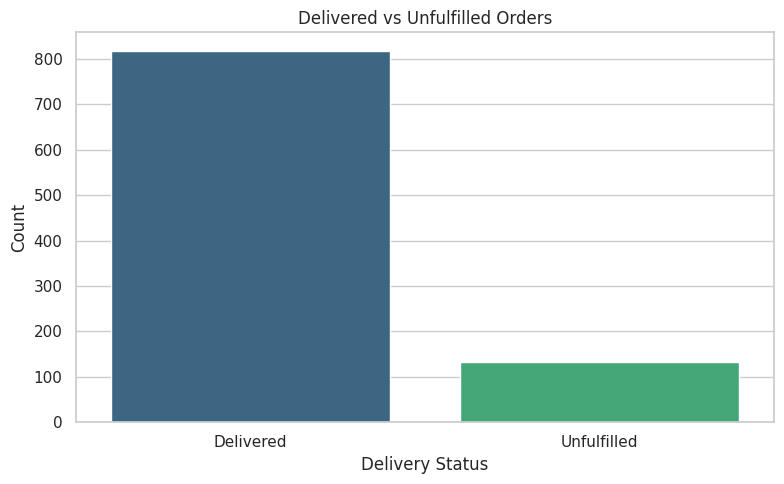

In [ ]:
# =========================
# 24. CHARTS - DELIVERY STATUS
# =========================
plt.figure(figsize=(8,5))
delivery_status_counts = merged_od["is_unfulfilled"].map({0: "Delivered", 1: "Unfulfilled"}).value_counts()
sns.barplot(x=delivery_status_counts.index, y=delivery_status_counts.values, palette="viridis")
plt.title("Delivered vs Unfulfilled Orders")
plt.xlabel("Delivery Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "delivered_vs_unfulfilled.png"), dpi=300)
plt.show()

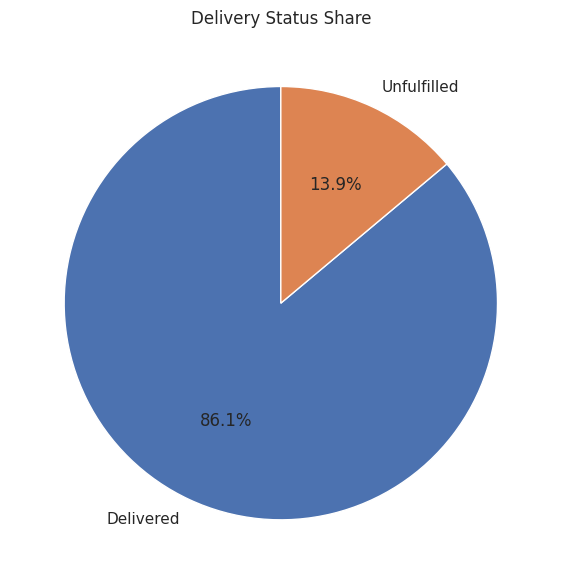

In [ ]:
# Pie chart
plt.figure(figsize=(6,6))
plt.pie(delivery_status_counts.values, labels=delivery_status_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Delivery Status Share")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "delivery_status_share_pie.png"), dpi=300)
plt.show()

/tmp/ipykernel_17420/901793380.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=late_counts.index, y=late_counts.values, palette="magma")


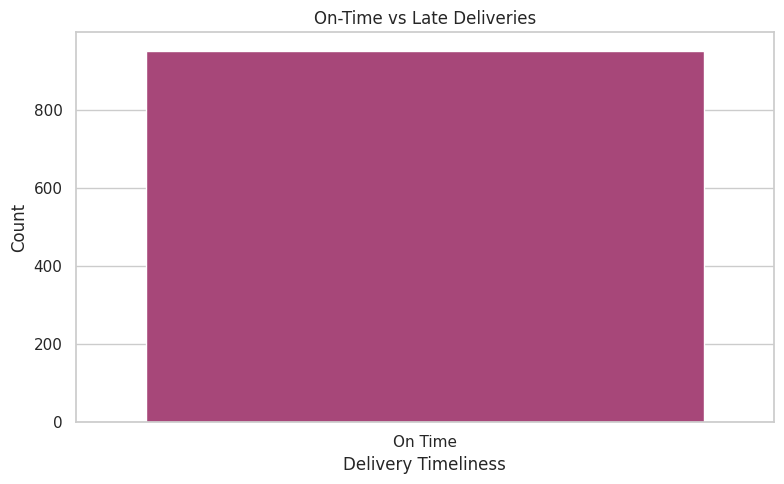

In [ ]:
# On-time vs late
plt.figure(figsize=(8,5))
late_counts = merged_od["late_delivery_flag"].map({0: "On Time", 1: "Late"}).value_counts()
sns.barplot(x=late_counts.index, y=late_counts.values, palette="magma")
plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Timeliness")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "on_time_vs_late.png"), dpi=300)
plt.show()

In [ ]:
# Delivery status by zone
if not zone_performance.empty:
    plt.figure(figsize=(12,6))
    zp = zone_performance.sort_values("unfulfilled_pct", ascending=False)
    sns.barplot(data=zp, x=zone_col_del, y="unfulfilled_pct", palette="rocket")
    plt.title("Unfulfilled Order Percentage by Zone")
    plt.xlabel("Zone")
    plt.ylabel("Unfulfilled %")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_PATH, "unfulfilled_by_zone.png"), dpi=300)
    plt.show()

In [ ]:
# Monthly delivery trend
if order_date_col in merged_od.columns and pd.api.types.is_datetime64_any_dtype(merged_od[order_date_col]):
    monthly_orders = (
        merged_od.assign(order_month_period=merged_od[order_date_col].dt.to_period("M").astype(str))
        .groupby("order_month_period")
        .size()
        .reset_index(name="order_count")
    )

    plt.figure(figsize=(12,6))
    sns.lineplot(data=monthly_orders, x="order_month_period", y="order_count", marker="o")
    plt.title("Monthly Order Trend")
    plt.xlabel("Month")
    plt.ylabel("Orders")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_PATH, "monthly_order_trend.png"), dpi=300)
    plt.show()

/tmp/ipykernel_17420/2806200956.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comp_cat, y="complaint_category_group", x="count", palette="crest")


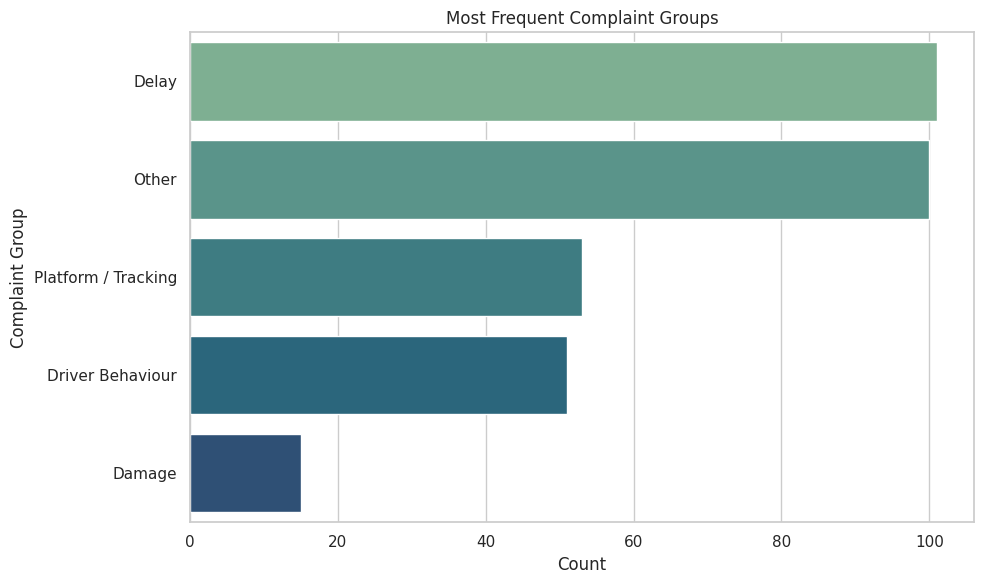

In [ ]:
# =========================
# 25. CHARTS - COMPLAINTS
# =========================
if "complaint_category_group" in complaints_fe.columns:
    plt.figure(figsize=(10,6))
    comp_cat = complaints_fe["complaint_category_group"].value_counts().reset_index()
    comp_cat.columns = ["complaint_category_group", "count"]
    sns.barplot(data=comp_cat, y="complaint_category_group", x="count", palette="crest")
    plt.title("Most Frequent Complaint Groups")
    plt.xlabel("Count")
    plt.ylabel("Complaint Group")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_PATH, "complaint_groups.png"), dpi=300)
    plt.show()

In [ ]:
# Complaint trend over time
if complaint_date_col and complaint_date_col in complaints_fe.columns and pd.api.types.is_datetime64_any_dtype(complaints_fe[complaint_date_col]):
    complaint_trend = (
        complaints_fe.assign(month=complaints_fe[complaint_date_col].dt.to_period("M").astype(str))
        .groupby("month")
        .size()
        .reset_index(name="complaint_count")
    )

    plt.figure(figsize=(12,6))
    sns.lineplot(data=complaint_trend, x="month", y="complaint_count", marker="o", color="firebrick")
    plt.title("Complaint Trend Over Time")
    plt.xlabel("Month")
    plt.ylabel("Complaint Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_PATH, "complaint_trend.png"), dpi=300)
    plt.show()

/tmp/ipykernel_17420/336758954.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inc_freq, y="incident_type", x="count", palette="flare")


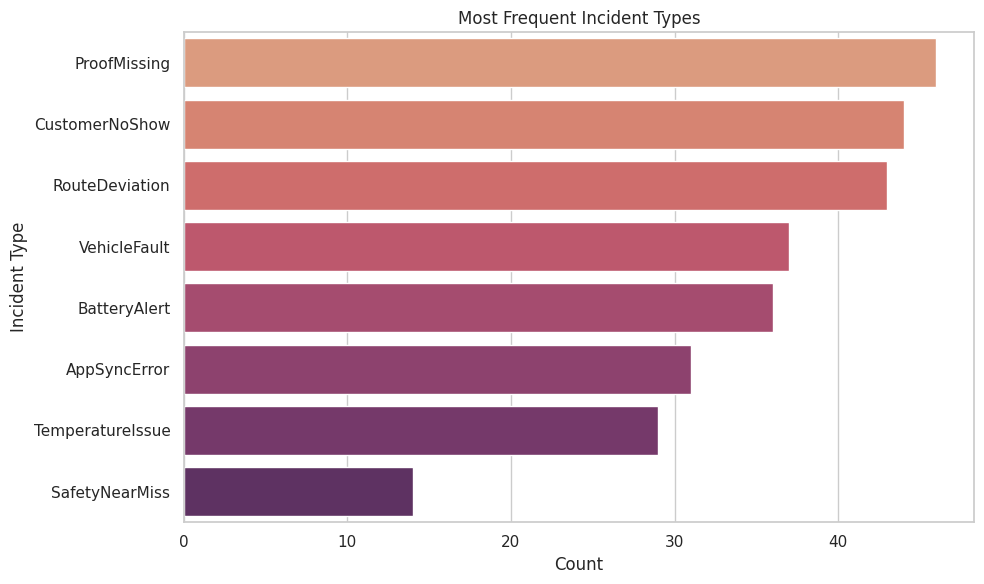

In [ ]:
# =========================
# 26. CHARTS - INCIDENTS
# =========================
if incident_type_col and incident_type_col in incidents_fe.columns:
    plt.figure(figsize=(10,6))
    inc_freq = incidents_fe[incident_type_col].value_counts().head(15).reset_index()
    inc_freq.columns = ["incident_type", "count"]
    sns.barplot(data=inc_freq, y="incident_type", x="count", palette="flare")
    plt.title("Most Frequent Incident Types")
    plt.xlabel("Count")
    plt.ylabel("Incident Type")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_PATH, "incident_types.png"), dpi=300)
    plt.show()

In [ ]:
# =========================
# 27. CLEANING SUMMARY
# =========================
cleaning_summary = []

for name, df in cleaned.items():
    if df.empty:
        continue
    cleaning_summary.append({
        "dataset": name,
        "rows_after_cleaning": len(df),
        "columns_after_cleaning": df.shape[1],
        "missing_cells_after_cleaning": int(df.isna().sum().sum()),
        "exact_duplicates_after_cleaning": int(df.duplicated().sum())
    })

cleaning_summary_df = pd.DataFrame(cleaning_summary)
cleaning_summary_df.to_csv(os.path.join(REPORTS_PATH, "cleaning_summary.csv"), index=False)
cleaning_summary_df

,dataset,rows_after_cleaning,columns_after_cleaning,missing_cells_after_cleaning,exact_duplicates_after_cleaning
0,app_events,640,11,0,0
1,complaints,320,10,0,0
2,customers,650,10,0,0
3,data_dictionary,9,3,0,0
4,deliveries,950,13,33,0
5,drivers,170,9,0,0
6,hubs,8,6,0,0
7,incidents,280,7,0,0
8,orders,1250,13,0,0
9,vehicles,120,9,0,0


In [ ]:
# =========================
# 28. SAVE CLEAN DATASETS
# =========================
# Replace originals with engineered versions where relevant
clean_orders = orders.copy()
clean_deliveries = deliveries_fe.copy()
clean_complaints = complaints_fe.copy()
clean_incidents = incidents_fe.copy()

clean_orders.to_csv(os.path.join(OUTPUT_PATH, "clean_orders.csv"), index=False)
clean_deliveries.to_csv(os.path.join(OUTPUT_PATH, "clean_deliveries.csv"), index=False)
clean_complaints.to_csv(os.path.join(OUTPUT_PATH, "clean_complaints.csv"), index=False)
clean_incidents.to_csv(os.path.join(OUTPUT_PATH, "clean_incidents.csv"), index=False)

# Save all cleaned tables too
for name, df in cleaned.items():
    if not df.empty:
        df.to_csv(os.path.join(OUTPUT_PATH, f"clean_{name}_base.csv"), index=False)

print("Saved clean datasets to:", OUTPUT_PATH)

Saved clean datasets to: /content/drive/MyDrive/northstar_dataset1/output


In [ ]:
# =========================
# 29. GENERATE A SIMPLE BUSINESS INSIGHT TEXT FILE
# =========================
insight_lines = []

if not zone_performance.empty:
    worst_zone_unfulfilled = zone_performance.sort_values("unfulfilled_pct", ascending=False).head(1)
    worst_zone_late = zone_performance.sort_values("late_delivery_rate_pct", ascending=False).head(1)

    if len(worst_zone_unfulfilled) > 0:
        insight_lines.append(
            f"Highest unfulfilled rate zone: {worst_zone_unfulfilled.iloc[0][zone_col_del]} "
            f"({worst_zone_unfulfilled.iloc[0]['unfulfilled_pct']:.2f}%)."
        )
    if len(worst_zone_late) > 0:
        insight_lines.append(
            f"Highest late delivery rate zone: {worst_zone_late.iloc[0][zone_col_del]} "
            f"({worst_zone_late.iloc[0]['late_delivery_rate_pct']:.2f}%)."
        )

if not driver_performance.empty:
    risky_driver = driver_performance.sort_values("anomaly_rate_pct", ascending=False).head(1)
    if len(risky_driver) > 0:
        insight_lines.append(
            f"Driver with highest anomaly rate: {risky_driver.iloc[0][driver_id_col_del]} "
            f"({risky_driver.iloc[0]['anomaly_rate_pct']:.2f}%)."
        )

if "complaint_category_group" in complaints_fe.columns:
    top_complaint = complaints_fe["complaint_category_group"].value_counts().head(1)
    if len(top_complaint) > 0:
        insight_lines.append(
            f"Most common complaint group: {top_complaint.index[0]} ({top_complaint.iloc[0]} records)."
        )

if "incident_severity" in incidents_fe.columns:
    sev_counts = incidents_fe["incident_severity"].value_counts()
    if len(sev_counts) > 0:
        insight_lines.append(
            f"Most common incident severity: {sev_counts.index[0]} ({sev_counts.iloc[0]} incidents)."
        )

insight_lines.append(f"Total orders analysed: {total_orders}.")
insight_lines.append(f"Unfulfilled orders: {unfulfilled_orders}.")

with open(os.path.join(REPORTS_PATH, "business_insights_summary.txt"), "w") as f:
    for line in insight_lines:
        f.write(line + "\n")

print("\n".join(insight_lines))

Driver with highest anomaly rate: D001 (0.00%).
Most common complaint group: Delay (101 records).
Most common incident severity: Low (280 incidents).
Total orders analysed: 950.
Unfulfilled orders: 132.


In [ ]:
# =========================
# 30. OPTIONAL SQL-LIKE CHECKS USING PANDAS
# =========================
# Complaints linked to unfulfilled deliveries
if comp_order_id_col and order_id_col and comp_order_id_col in complaints_fe.columns and order_id_col in merged_od.columns:
    complaints_with_order_status = complaints_fe.merge(
        merged_od[[order_id_col, "is_unfulfilled", "late_delivery_flag"]].drop_duplicates(),
        left_on=comp_order_id_col,
        right_on=order_id_col,
        how="left"
    )

    linked_summary = complaints_with_order_status.groupby("is_unfulfilled").size().reset_index(name="complaint_count")
    linked_summary.to_csv(os.path.join(REPORTS_PATH, "complaints_linked_to_unfulfilled_summary.csv"), index=False)
    print(linked_summary.head())

   is_unfulfilled  complaint_count
0             0.0              197
1             1.0               35


In [ ]:
# =========================
# 31. FINAL FILE CHECK
# =========================
for root, dirs, files in os.walk(OUTPUT_PATH):
    level = root.replace(OUTPUT_PATH, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

output/
    zone_master_table.csv
    clean_orders.csv
    clean_deliveries.csv
    clean_complaints.csv
    clean_incidents.csv
    clean_app_events_base.csv
    clean_complaints_base.csv
    clean_customers_base.csv
    clean_data_dictionary_base.csv
    clean_deliveries_base.csv
    clean_drivers_base.csv
    clean_hubs_base.csv
    clean_incidents_base.csv
    clean_orders_base.csv
    clean_vehicles_base.csv
    plots/
        delivered_vs_unfulfilled.png
        delivery_status_share_pie.png
        on_time_vs_late.png
        complaint_groups.png
        incident_types.png
    reports/
        dataset_profile_summary.csv
        relationship_key_guess.csv
        missing_value_summary.csv
        conversion_log.csv
        missingness_by_group.csv
        duplicate_report.csv
        imputation_log.csv
        business_metrics_summary.csv
        driver_performance_summary.csv
        cleaning_summary.csv
        business_insights_summary.txt
        complaints_linked_to_unfulfi